In [3]:
%matplotlib widget

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [5]:
n_component = 6

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, theta):
    # theta è un array 1D o DataFrame
    if isinstance(theta, np.ndarray):
        params = theta
    else:
        params = theta.values.flatten()
    
    x_hr = np.linspace(min(x), max(x), 4000)
    
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def single_integral(x, params, a, b):
    # x --> array di x 
    # y --> dati sulla y (sersic_1d_conv(x))
    # params --> parametri del profilo 
    # a e b --> estremi di integrazione
    func = sersic_1d_convolved(x, params)
    mask = (x >= a)*(x <= b)
    integral = simpson(y = func[mask], x = x[mask])
    return integral 

def total_integral(x, params1, params2, params3, params4, params5, params6, a, b):
    func = model_convolved(x, params1, params2, params3, params4, params5, params6)
    mask = (x >= a)*(x <= b)
    integral = simpson(y = func[mask], x = x[mask])
    return integral  

def contamination(x, params1, params2, params3, params4, params5, params6, a, b): 
    blue_area = single_integral(x, params1, a, b) 
    green_area = single_integral(x, params2, a, b)
    magenta_area = single_integral(x, params3, a, b)
    orange_area = single_integral(x, params4, a, b)
    choco_area = single_integral(x, params5, a, b)
    purple_area = single_integral(x, params6, a, b)
    #pink_area = single_integral(x, params7, a, b)
    sum_area = blue_area + green_area + magenta_area + orange_area + choco_area + purple_area
    total_area = total_integral(x, params1, params2, params3, params4, params5, params6, a, b)
    print(sum_area)
    print(total_area)
    return [(blue_area*100)/sum_area, (green_area*100)/sum_area, (magenta_area*100)/sum_area, 
            (orange_area*100)/sum_area, (choco_area*100)/sum_area, (purple_area*100)/sum_area]#, (pink_area*100)/sum_area]     

In [6]:
flat_samples = np.load('flat_samples.npy') #flat sample, burn-in=1000, thin=100
print(flat_samples.shape)
print(flat_samples[0])

(49500, 24)
[ 1.51970223  9.51509123  2.79058662 16.64328679  2.09134852  5.72712058
  3.28284153 41.61516051  8.22318768  6.37038697  0.84900103 60.53426148
 11.09469216  3.30933101  0.84098632 65.87758877  5.98165755  5.04406736
  1.53493132 72.51410698  0.93077419  8.160214    1.24763738 91.2377759 ]


Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     363   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        44   (2094, 964)   float32   


Text(0.5, 1.0, 'H$\\alpha$')

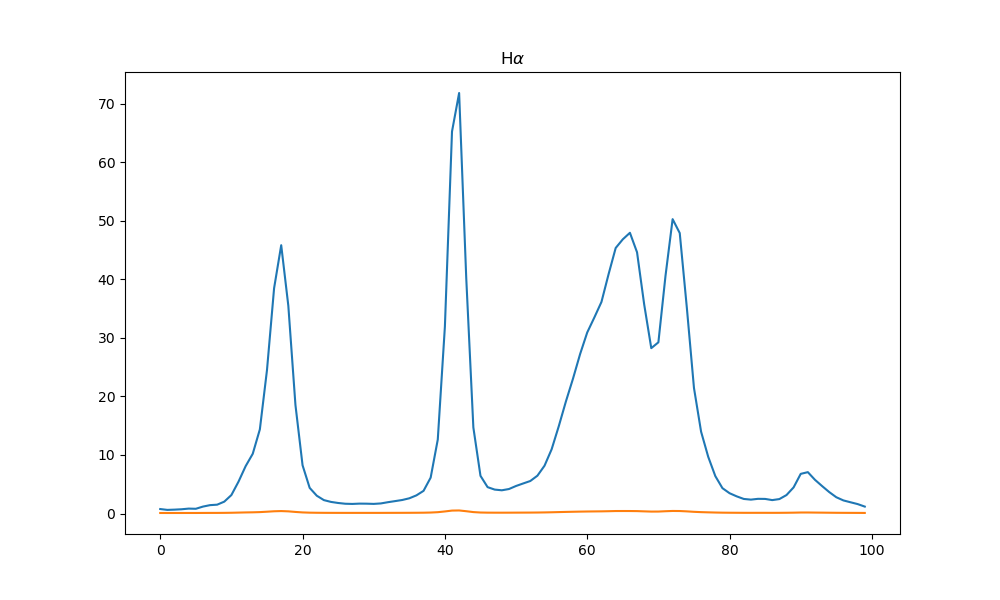

In [7]:
seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/PSF/Real_seeing_FIRST_1.txt")
sigmas = seeing / 2.35
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

image_cut = image[49:149, 0:1890]
image_error_cut = image_error[49:149, 0:1890]
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

z = 0.04263
l_HA = 6563 * (1+z)

mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

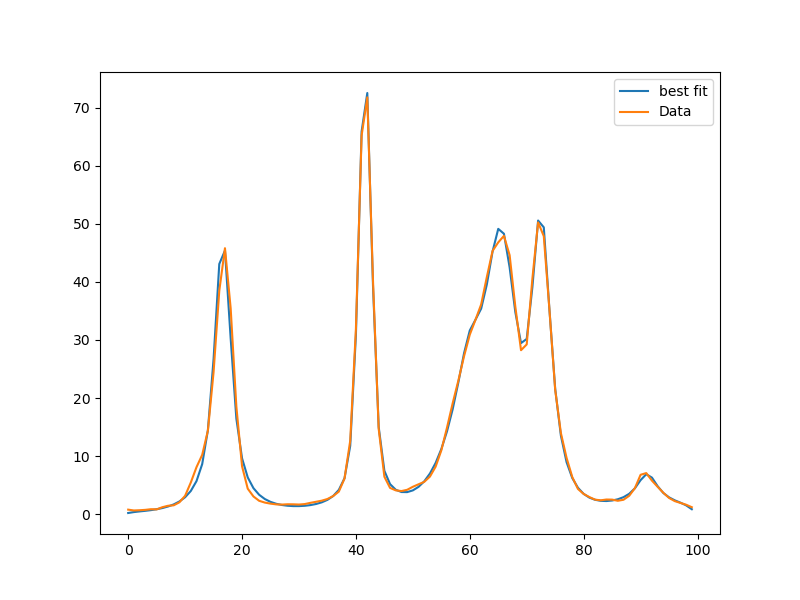

In [8]:
sampler = emcee.backends.HDFBackend("MCMC_params.h5", read_only=True)
log_prob = sampler.get_log_prob(discard=1000, thin=100, flat=True)
max_idx = np.argmax(log_prob)
best_fit = flat_samples[max_idx]
plt.figure(figsize = (8, 6))
x_axes = np.arange(0, 100, 1)
best_model = model_convolved(x_axes, sigmas[0], best_fit)
plt.plot(x_axes, best_model, label = 'best fit')
plt.plot(x_axes, radial_profile_HA, label = 'Data')
plt.legend()
plt.savefig('best_fit')

In [9]:
def LogLikelihood(x, theta, sigma_y, y):
    model_values = model_convolved(x, sigmas[0], theta)
    return -0.5 * np.sum((y - model_values)**2 / sigma_y**2)
    
fit = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Fit/Halpha_fit.csv", index_col=0)
params_fit = np.array([fit['Component 1'], fit['Component 2'], 
                           fit['Component 3'], fit['Component 4'], fit['Component 5'], fit['Component 6']]).flatten()
print('Loglikehood best fit MCMC:', LogLikelihood(x_axes, best_fit, radial_profile_error_HA, radial_profile_HA))
print('Loglikehood fit:', LogLikelihood(x_axes, params_fit, radial_profile_error_HA, radial_profile_HA))

Loglikehood best fit MCMC: -868.2842376017157
Loglikehood fit: -1164.6976332694521


In [10]:
params_fit

array([ 1.3189, 10.9768,  2.842 , 16.6268,  2.8302,  4.6566,  3.0356,
       41.6152,  6.5184,  6.9821,  0.8845, 60.321 ,  9.3911,  4.4883,
        0.9674, 65.5906,  4.7418,  5.5578,  1.7061, 72.5908,  0.9772,
        6.7674,  1.37  , 91.2633])

In [11]:
model_values = np.zeros((flat_samples.shape[0], len(x_axes)))
comp_1_values = np.zeros((flat_samples.shape[0], len(x_axes)))
comp_2_values = np.zeros((flat_samples.shape[0], len(x_axes)))
comp_3_values = np.zeros((flat_samples.shape[0], len(x_axes)))
comp_4_values = np.zeros((flat_samples.shape[0], len(x_axes)))
comp_5_values = np.zeros((flat_samples.shape[0], len(x_axes)))
comp_6_values = np.zeros((flat_samples.shape[0], len(x_axes)))

from tqdm import tqdm

for i in tqdm(range(len(flat_samples)), desc="Processing samples"):
    model_values[i] = model_convolved(x_axes, sigmas[0], flat_samples[i])
    comp_1_values[i] = sersic_1d(x_axes, *flat_samples[i][0:4])
    comp_2_values[i] = sersic_1d(x_axes, *flat_samples[i][4:8])
    comp_3_values[i] = sersic_1d(x_axes, *flat_samples[i][8:12])
    comp_4_values[i] = sersic_1d(x_axes, *flat_samples[i][12:16])
    comp_5_values[i] = sersic_1d(x_axes, *flat_samples[i][16:20])
    comp_6_values[i] = sersic_1d(x_axes, *flat_samples[i][20:24])

Processing samples: 100%|███████████████████████████████████████████████████████| 49500/49500 [03:55<00:00, 209.95it/s]


In [12]:
np.save('model.npy', model_values)
np.save('component_1.npy', comp_1_values)
np.save('component_2.npy', comp_2_values)
np.save('component_3.npy', comp_3_values)
np.save('component_4.npy', comp_4_values)
np.save('component_5.npy', comp_5_values)
np.save('component_6.npy', comp_6_values)

In [13]:
model_values = np.load('model.npy')
comp_1_values = np.load('component_1.npy')
comp_2_values = np.load('component_2.npy')
comp_3_values = np.load('component_3.npy')
comp_4_values = np.load('component_4.npy')
comp_5_values = np.load('component_5.npy')
comp_6_values = np.load('component_6.npy')

In [14]:
def statistica(array):
    median = np.median(array, axis = 0)
    perc_16 = np.percentile(array, 16, axis = 0)
    perc_84 = np.percentile(array, 84, axis = 0)
    return median, perc_16, perc_84
    
model_median, model_16, model_84 = statistica(model_values)
comp_1_median, comp_1_16, comp_1_84 = statistica(comp_1_values)
comp_2_median, comp_2_16, comp_2_84 = statistica(comp_2_values)
comp_3_median, comp_3_16, comp_3_84 = statistica(comp_3_values)
comp_4_median, comp_4_16, comp_4_84 = statistica(comp_4_values)
comp_5_median, comp_5_16, comp_5_84 = statistica(comp_5_values)
comp_6_median, comp_6_16, comp_6_84 = statistica(comp_6_values)

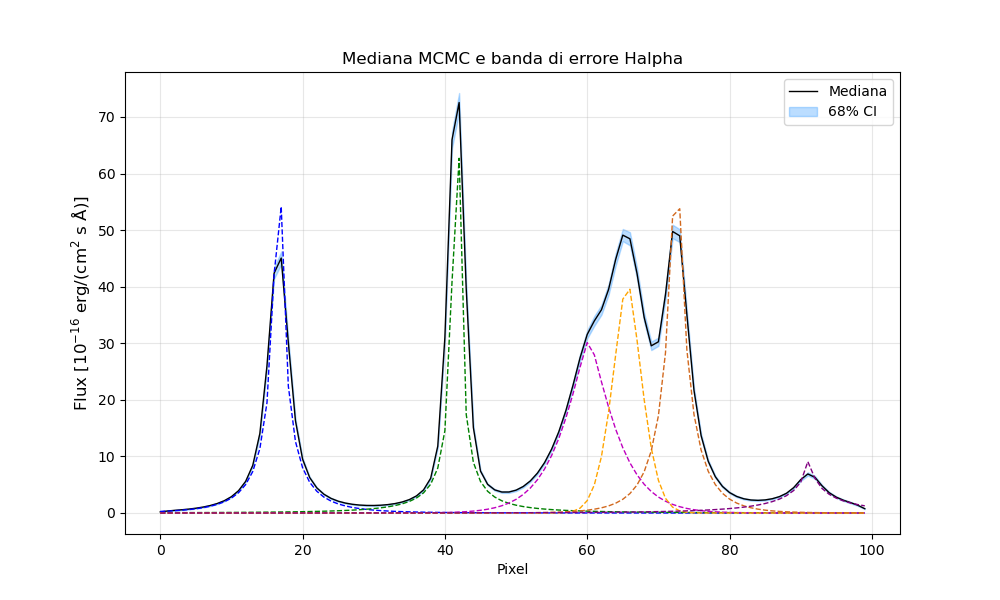

In [15]:
# Plot con bande di errore
plt.figure(figsize=(10, 6))
plt.title('Mediana MCMC e banda di errore Halpha')
plt.plot(x_axes, model_median, 'k-', label='Mediana', linewidth=1)
plt.plot(x_axes, comp_1_median, 'blue', linewidth=1, linestyle = '--')
plt.plot(x_axes, comp_2_median, 'g', linewidth=1, linestyle = '--')
plt.plot(x_axes, comp_3_median, 'm', linewidth=1, linestyle = '--')
plt.plot(x_axes, comp_4_median, 'orange', linewidth=1, linestyle = '--')
plt.plot(x_axes, comp_5_median, 'chocolate', linewidth=1, linestyle = '--')
plt.plot(x_axes, comp_6_median, 'purple', linewidth=1, linestyle = '--')
#plt.plot(x_axes, radial_profile_HA, label = 'data')
plt.fill_between(x_axes, model_16, model_84, alpha=0.3, label='68% CI', color = 'dodgerblue')
plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
plt.xlabel('Pixel')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()
plt.savefig('Fit_con_errori')

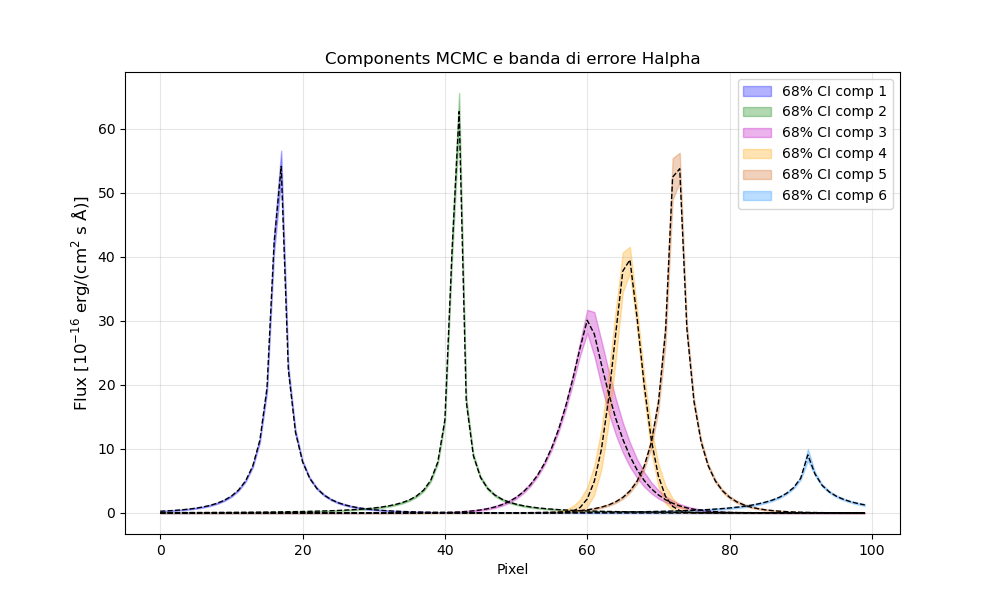

In [16]:
plt.figure(figsize=(10, 6))
plt.title('Components MCMC e banda di errore Halpha')
plt.plot(x_axes, comp_1_median, 'k', linewidth=1, linestyle = '--')
plt.fill_between(x_axes, comp_1_16, comp_1_84, alpha=0.3, label='68% CI comp 1', color = 'blue')

plt.plot(x_axes, comp_2_median, 'k', linewidth=1, linestyle = '--')
plt.fill_between(x_axes, comp_2_16, comp_2_84, alpha=0.3, label='68% CI comp 2', color = 'g')

plt.plot(x_axes, comp_3_median, 'k', linewidth=1, linestyle = '--')
plt.fill_between(x_axes, comp_3_16, comp_3_84, alpha=0.3, label='68% CI comp 3', color = 'm')

plt.plot(x_axes, comp_4_median, 'k', linewidth=1, linestyle = '--')
plt.fill_between(x_axes, comp_4_16, comp_4_84, alpha=0.3, label='68% CI comp 4', color = 'orange')

plt.plot(x_axes, comp_5_median, 'k', linewidth=1, linestyle = '--')
plt.fill_between(x_axes, comp_5_16, comp_5_84, alpha=0.3, label='68% CI comp 5', color = 'chocolate')

plt.plot(x_axes, comp_6_median, 'k', linewidth=1, linestyle = '--')
plt.fill_between(x_axes, comp_6_16, comp_6_84, alpha=0.3, label='68% CI comp 6', color = 'dodgerblue')

plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]', fontsize=12)
plt.xlabel('Pixel')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()
plt.savefig('Component_fit_errors')

In [17]:
sigmas[-1]

1.071513696832815

In [18]:
from scipy.integrate import simpson

# Inizializza array
n_samples = len(flat_samples)
all_areas = np.zeros((n_samples, 6, 6))  # (sample, componente, picco)

# Lista delle componenti già calcolate
comp_values_list = [comp_1_values, comp_2_values, comp_3_values, 
                     comp_4_values, comp_5_values, comp_6_values]

# Calcola le aree per tutti i campioni
for i in tqdm(range(n_samples), desc="Calculating areas"):
    theta = flat_samples[i]
    
    # Per ogni picco (centrato sulla componente corrispondente)
    for peak_idx in range(6):
        # L'intervallo di integrazione è centrato sulla componente peak_idx
        x0_peak = theta[peak_idx*4 + 3]  # x_0 della componente del picco
        a = x0_peak - sigmas[-1]
        b = x0_peak + sigmas[-1]
        mask = (x_axes >= a) & (x_axes <= b)
        
        # Calcola l'area della componente in questo intervallo
        single_areas = np.zeros(6)
        for comp_idx in range(6):
            func = comp_values_list[comp_idx][i]
            single_areas[comp_idx] = simpson(y=func[mask], x=x_axes[mask])
        
        # Converti in percentuali
        sum_area = single_areas.sum()
        if sum_area > 0:  # Evita divisione per zero
            all_areas[i, :, peak_idx] = (single_areas * 100) / sum_area
        else:
            all_areas[i, :, peak_idx] = 0

# Salva
np.save('mcmc_areas_1s.npy', all_areas)

Calculating areas: 100%|████████████████████████████████████████████████████████| 49500/49500 [00:58<00:00, 846.29it/s]


In [19]:
# Calcola statistiche
median_areas = np.median(all_areas, axis=0)
p16_areas = np.percentile(all_areas, 16, axis=0)
p84_areas = np.percentile(all_areas, 84, axis=0)

# Crea DataFrame
components = ['Blue', 'Green', 'Magenta', 'Orange', 'Chocolate', 'Dodgerblue']
peaks = [f'Peak {i+1}' for i in range(6)]

df_median = pd.DataFrame(median_areas, columns=peaks, index=components)
df_err_low = pd.DataFrame(median_areas - p16_areas, columns=peaks, index=components)
df_err_high = pd.DataFrame(p84_areas - median_areas, columns=peaks, index=components)

# Stampa risultati formattati
print("Mediane e errori:")
for i, comp in enumerate(components):
    print(f"\n{comp}:")
    for j, peak in enumerate(peaks):
        med = median_areas[i, j]
        err_l = df_err_low.iloc[i, j]
        err_h = df_err_high.iloc[i, j]
        print(f"  {peak}: {med:.2f} +{err_h:.2f} -{err_l:.2f} %")

# Salva i tre DataFrame separati
df_median.to_csv('areas_median_1s.csv')
df_err_low.to_csv('areas_err_low_1s.csv')
df_err_high.to_csv('areas_err_high_1s.csv')

#Salva anche il DataFrame combinato
df_combined = pd.DataFrame(index=components, columns=peaks)
for i, comp in enumerate(components):
    for j, peak in enumerate(peaks):
        med = median_areas[i, j]
        err_l = df_err_low.iloc[i, j]
        err_h = df_err_high.iloc[i, j]
        df_combined.loc[comp, peak] = f"{med:.2f} +{err_h:.2f} -{err_l:.2f}"
df_combined.to_csv('areas_with_errors_1s.csv')

print("\nFile salvati:")
print("- areas_median_1s.csv (mediane)")
print("- areas_err_low_1s.csv (errori inferiori)")
print("- areas_err_high_1s.csv (errori superiori)")
print("- areas_with_errors_1s.csv (combinato)")

Mediane e errori:

Blue:
  Peak 1: 99.63 +0.08 -0.04 %
  Peak 2: 0.14 +0.05 -0.04 %
  Peak 3: 0.02 +0.02 -0.01 %
  Peak 4: 0.01 +0.01 -0.00 %
  Peak 5: 0.00 +0.00 -0.00 %
  Peak 6: 0.00 +0.01 -0.00 %

Green:
  Peak 1: 0.35 +0.04 -0.08 %
  Peak 2: 99.51 +0.11 -0.15 %
  Peak 3: 0.94 +0.13 -0.18 %
  Peak 4: 0.36 +0.04 -0.08 %
  Peak 5: 0.19 +0.03 -0.05 %
  Peak 6: 0.45 +0.09 -0.16 %

Magenta:
  Peak 1: 0.00 +0.00 -0.00 %
  Peak 2: 0.27 +0.13 -0.09 %
  Peak 3: 88.56 +3.40 -5.20 %
  Peak 4: 19.50 +4.48 -3.47 %
  Peak 5: 2.36 +0.64 -0.50 %
  Peak 6: 0.02 +0.03 -0.01 %

Orange:
  Peak 1: 0.00 +0.00 -0.00 %
  Peak 2: 0.00 +0.00 -0.00 %
  Peak 3: 8.52 +5.19 -3.37 %
  Peak 4: 74.21 +3.52 -4.50 %
  Peak 5: 1.26 +1.88 -0.75 %
  Peak 6: 0.00 +0.00 -0.00 %

Chocolate:
  Peak 1: 0.00 +0.00 -0.00 %
  Peak 2: 0.01 +0.01 -0.00 %
  Peak 3: 1.64 +0.38 -0.33 %
  Peak 4: 5.61 +0.50 -0.49 %
  Peak 5: 95.49 +0.80 -1.76 %
  Peak 6: 1.08 +0.53 -0.35 %

Dodgerblue:
  Peak 1: 0.01 +0.01 -0.01 %
  Peak 2: 0.05 +0.

In [20]:
all_areas.shape

(49500, 6, 6)

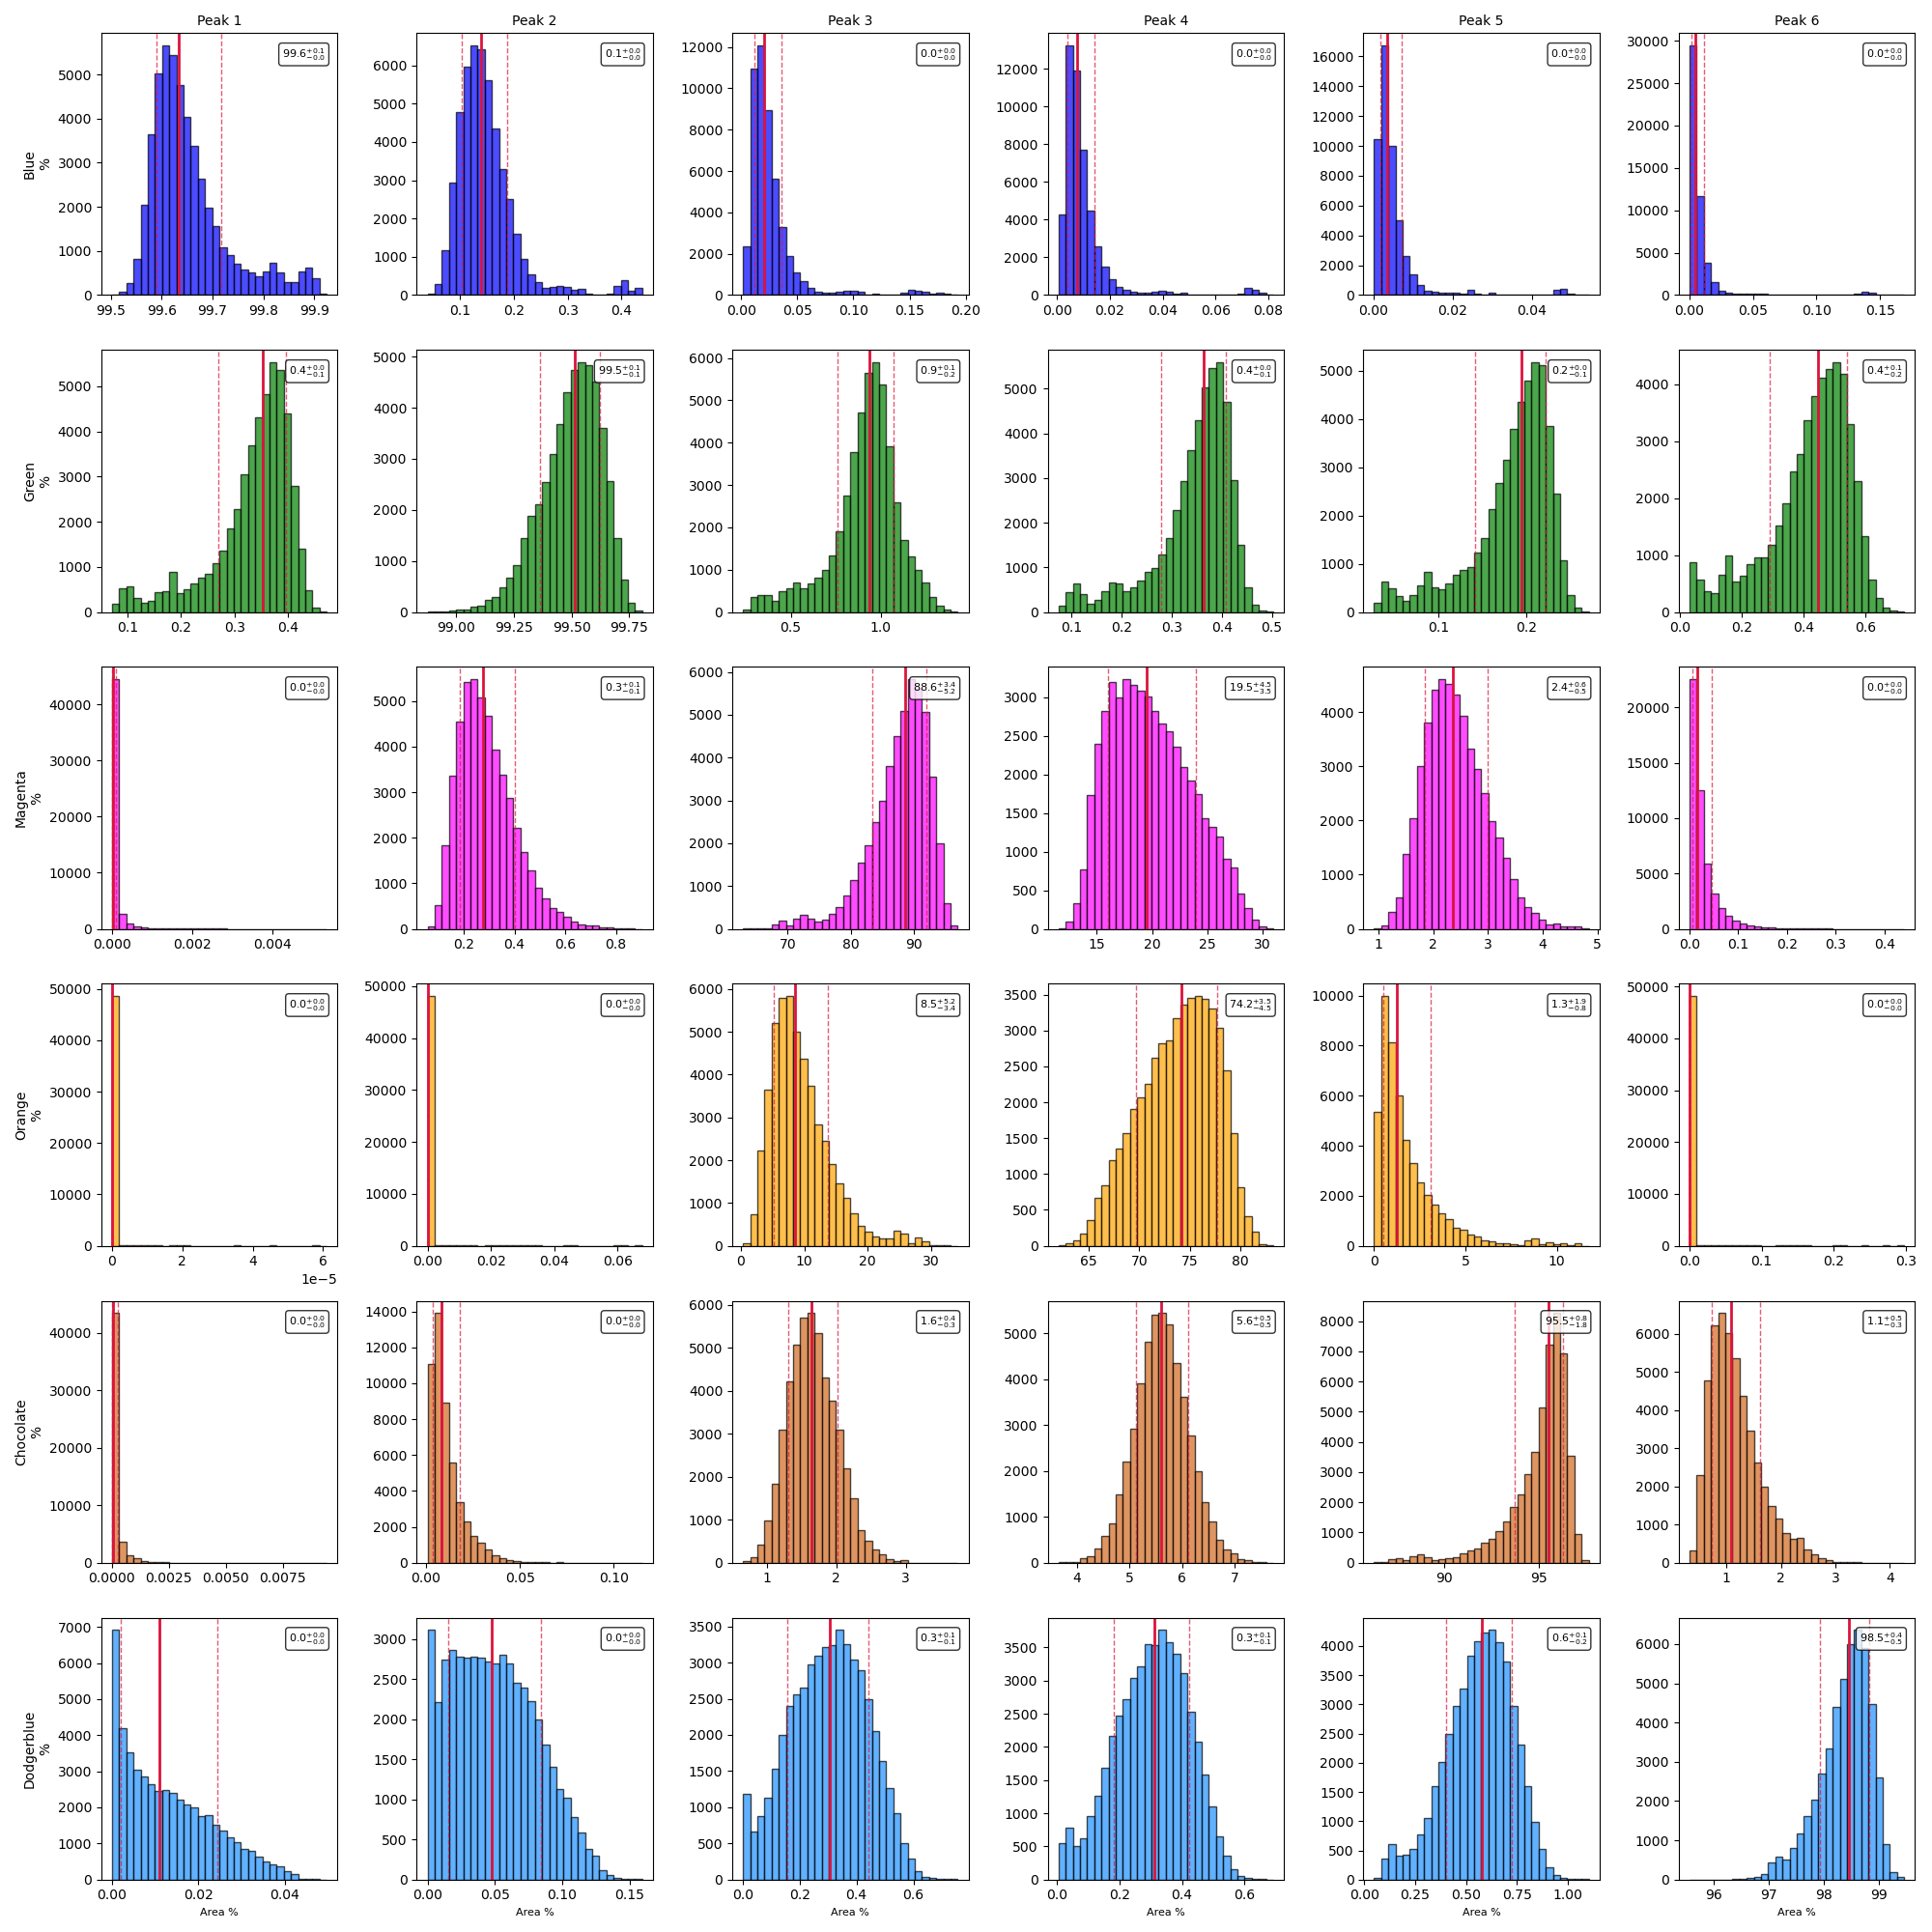

In [21]:
# Plot di tutte le distribuzioni (6x6 = 36 subplot)
fig, axes = plt.subplots(6, 6, figsize=(20, 20))
components = ['Blue', 'Green', 'Magenta', 'Orange', 'Chocolate', 'Dodgerblue']
peaks = [f'Peak {i+1}' for i in range(6)]
colors = ['blue', 'green', 'magenta', 'orange', 'chocolate', 'dodgerblue']

for comp_idx in range(6):
    for peak_idx in range(6):
        ax = axes[comp_idx, peak_idx]
        data = all_areas[:, comp_idx, peak_idx]
        
        # Istogramma
        ax.hist(data, bins=30, alpha=0.7, edgecolor='black', color=colors[comp_idx])
        
        # Aggiungi mediana e percentili
        median = np.median(data)
        p16 = np.percentile(data, 16)
        p84 = np.percentile(data, 84)
        
        ax.axvline(median, color='crimson', linestyle='-', linewidth=2, label='Mediana')
        ax.axvline(p16, color='crimson', linestyle='--', linewidth=1, alpha=0.7)
        ax.axvline(p84, color='crimson', linestyle='--', linewidth=1, alpha=0.7)
        
        # Titoli e label
        if comp_idx == 0:
            ax.set_title(peaks[peak_idx], fontsize=10)
        if peak_idx == 0:
            ax.set_ylabel(f'{components[comp_idx]}\n%', fontsize=10)
        if comp_idx == 5:
            ax.set_xlabel('Area %', fontsize=8)
        
        # Aggiungi testo con statistiche
        ax.text(0.95, 0.95, f'{median:.1f}$^{{+{p84-median:.1f}}}_{{-{median-p16:.1f}}}$',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('distributions_all_areas_1s.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Inizializza array
n_samples = len(flat_samples)
all_areas = np.zeros((n_samples, 6, 6))  # (sample, componente, picco)

# Lista delle componenti già calcolate
comp_values_list = [comp_1_values, comp_2_values, comp_3_values, 
                     comp_4_values, comp_5_values, comp_6_values]

# Calcola le aree per tutti i campioni
for i in tqdm(range(n_samples), desc="Calculating areas"):
    theta = flat_samples[i]
    
    # Per ogni picco (centrato sulla componente corrispondente)
    for peak_idx in range(6):
        # L'intervallo di integrazione è centrato sulla componente peak_idx
        x0_peak = theta[peak_idx*4 + 3]  # x_0 della componente del picco
        a = x0_peak - 2*sigmas[-1]
        b = x0_peak + 2*sigmas[-1]
        mask = (x_axes >= a) & (x_axes <= b)
        
        # Calcola l'area della componente in questo intervallo
        single_areas = np.zeros(6)
        for comp_idx in range(6):
            func = comp_values_list[comp_idx][i]
            single_areas[comp_idx] = simpson(y=func[mask], x=x_axes[mask])
        
        # Converti in percentuali
        sum_area = single_areas.sum()
        if sum_area > 0:  # Evita divisione per zero
            all_areas[i, :, peak_idx] = (single_areas * 100) / sum_area
        else:
            all_areas[i, :, peak_idx] = 0

# Salva
np.save('mcmc_areas_2s.npy', all_areas)

Calculating areas: 100%|█████████████████████████████████████████████████████████| 49500/49500 [09:21<00:00, 88.22it/s]


In [23]:
# Calcola statistiche
median_areas = np.median(all_areas, axis=0)
p16_areas = np.percentile(all_areas, 16, axis=0)
p84_areas = np.percentile(all_areas, 84, axis=0)

# Crea DataFrame
components = ['Blue', 'Green', 'Magenta', 'Orange', 'Chocolate', 'Dodgerblue']
peaks = [f'Peak {i+1}' for i in range(6)]

df_median = pd.DataFrame(median_areas, columns=peaks, index=components)
df_err_low = pd.DataFrame(median_areas - p16_areas, columns=peaks, index=components)
df_err_high = pd.DataFrame(p84_areas - median_areas, columns=peaks, index=components)

# Stampa risultati formattati
print("Mediane e errori:")
for i, comp in enumerate(components):
    print(f"\n{comp}:")
    for j, peak in enumerate(peaks):
        med = median_areas[i, j]
        err_l = df_err_low.iloc[i, j]
        err_h = df_err_high.iloc[i, j]
        print(f"  {peak}: {med:.2f} +{err_h:.2f} -{err_l:.2f} %")

# Salva i tre DataFrame separati
df_median.to_csv('areas_median_2s.csv')
df_err_low.to_csv('areas_err_low_2s.csv')
df_err_high.to_csv('areas_err_high_2s.csv')

#Salva anche il DataFrame combinato
df_combined = pd.DataFrame(index=components, columns=peaks)
for i, comp in enumerate(components):
    for j, peak in enumerate(peaks):
        med = median_areas[i, j]
        err_l = df_err_low.iloc[i, j]
        err_h = df_err_high.iloc[i, j]
        df_combined.loc[comp, peak] = f"{med:.2f} +{err_h:.2f} -{err_l:.2f}"
df_combined.to_csv('areas_with_errors_2s.csv')

print("\nFile salvati:")
print("- areas_median_2s.csv (mediane)")
print("- areas_err_low_2s.csv (errori inferiori)")
print("- areas_err_high_2s.csv (errori superiori)")
print("- areas_with_errors_2s.csv (combinato)")

Mediane e errori:

Blue:
  Peak 1: 99.57 +0.10 -0.05 %
  Peak 2: 0.17 +0.06 -0.04 %
  Peak 3: 0.02 +0.02 -0.01 %
  Peak 4: 0.01 +0.01 -0.00 %
  Peak 5: 0.00 +0.00 -0.00 %
  Peak 6: 0.01 +0.01 -0.00 %

Green:
  Peak 1: 0.42 +0.05 -0.10 %
  Peak 2: 99.39 +0.14 -0.19 %
  Peak 3: 0.97 +0.15 -0.19 %
  Peak 4: 0.38 +0.05 -0.09 %
  Peak 5: 0.22 +0.03 -0.06 %
  Peak 6: 0.53 +0.12 -0.19 %

Magenta:
  Peak 1: 0.00 +0.00 -0.00 %
  Peak 2: 0.35 +0.16 -0.11 %
  Peak 3: 86.20 +3.67 -4.98 %
  Peak 4: 20.62 +4.63 -3.70 %
  Peak 5: 2.71 +0.73 -0.57 %
  Peak 6: 0.02 +0.04 -0.01 %

Orange:
  Peak 1: 0.00 +0.00 -0.00 %
  Peak 2: 0.00 +0.00 -0.00 %
  Peak 3: 10.71 +4.97 -3.62 %
  Peak 4: 72.61 +3.74 -4.80 %
  Peak 5: 1.72 +2.13 -0.93 %
  Peak 6: 0.00 +0.00 -0.00 %

Chocolate:
  Peak 1: 0.00 +0.00 -0.00 %
  Peak 2: 0.01 +0.01 -0.01 %
  Peak 3: 1.75 +0.39 -0.33 %
  Peak 4: 6.08 +0.56 -0.51 %
  Peak 5: 94.58 +0.94 -2.01 %
  Peak 6: 1.39 +0.66 -0.45 %

Dodgerblue:
  Peak 1: 0.01 +0.02 -0.01 %
  Peak 2: 0.06 +0

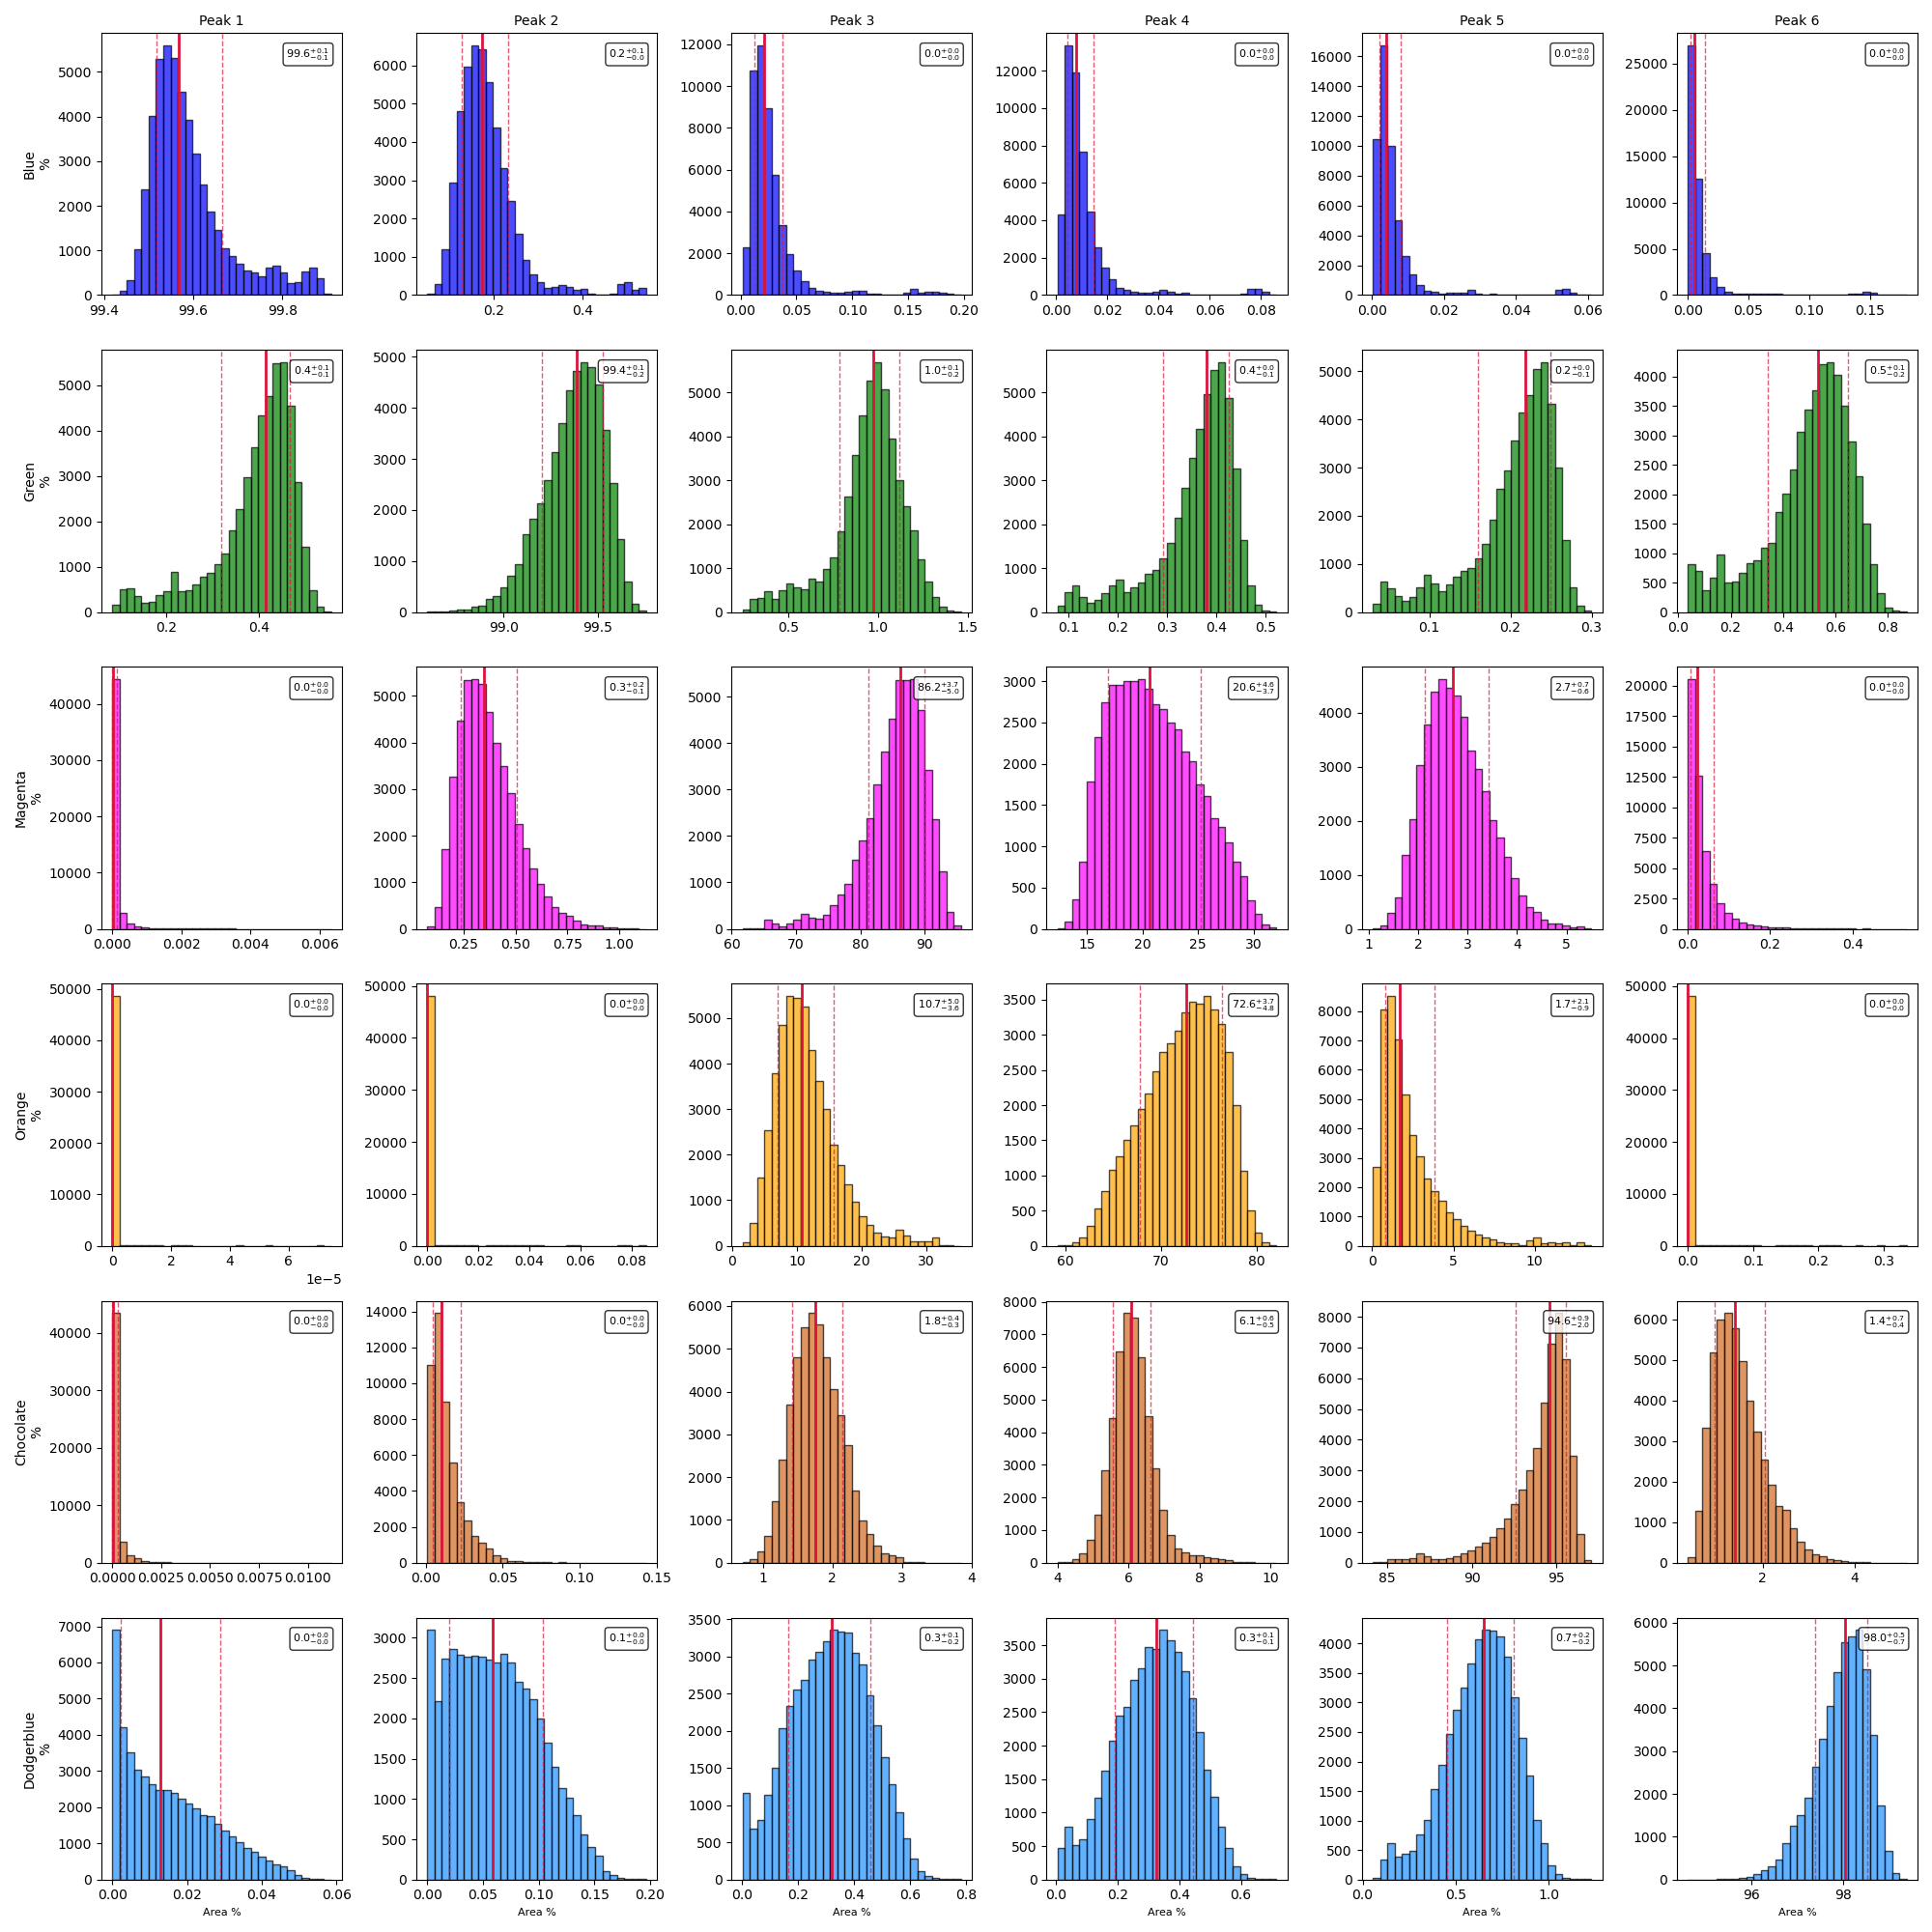

In [24]:
# Plot di tutte le distribuzioni (6x6 = 36 subplot)
fig, axes = plt.subplots(6, 6, figsize=(20, 20))
components = ['Blue', 'Green', 'Magenta', 'Orange', 'Chocolate', 'Dodgerblue']
peaks = [f'Peak {i+1}' for i in range(6)]
colors = ['blue', 'green', 'magenta', 'orange', 'chocolate', 'dodgerblue']

for comp_idx in range(6):
    for peak_idx in range(6):
        ax = axes[comp_idx, peak_idx]
        data = all_areas[:, comp_idx, peak_idx]
        
        # Istogramma
        ax.hist(data, bins=30, alpha=0.7, edgecolor='black', color=colors[comp_idx])
        
        # Aggiungi mediana e percentili
        median = np.median(data)
        p16 = np.percentile(data, 16)
        p84 = np.percentile(data, 84)
        
        ax.axvline(median, color='crimson', linestyle='-', linewidth=2, label='Mediana')
        ax.axvline(p16, color='crimson', linestyle='--', linewidth=1, alpha=0.7)
        ax.axvline(p84, color='crimson', linestyle='--', linewidth=1, alpha=0.7)
        
        # Titoli e label
        if comp_idx == 0:
            ax.set_title(peaks[peak_idx], fontsize=10)
        if peak_idx == 0:
            ax.set_ylabel(f'{components[comp_idx]}\n%', fontsize=10)
        if comp_idx == 5:
            ax.set_xlabel('Area %', fontsize=8)
        
        # Aggiungi testo con statistiche
        ax.text(0.95, 0.95, f'{median:.1f}$^{{+{p84-median:.1f}}}_{{-{median-p16:.1f}}}$',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('distributions_all_areas_2s.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Inizializza array
n_samples = len(flat_samples)
all_areas = np.zeros((n_samples, 6, 6))  # (sample, componente, picco)

# Lista delle componenti già calcolate
comp_values_list = [comp_1_values, comp_2_values, comp_3_values, 
                     comp_4_values, comp_5_values, comp_6_values]

# Calcola le aree per tutti i campioni
for i in tqdm(range(n_samples), desc="Calculating areas"):
    theta = flat_samples[i]
    
    # Per ogni picco (centrato sulla componente corrispondente)
    for peak_idx in range(6):
        # L'intervallo di integrazione è centrato sulla componente peak_idx
        x0_peak = theta[peak_idx*4 + 3]  # x_0 della componente del picco
        a = x0_peak - 3*sigmas[-1]
        b = x0_peak + 3*sigmas[-1]
        mask = (x_axes >= a) & (x_axes <= b)
        
        # Calcola l'area della componente in questo intervallo
        single_areas = np.zeros(6)
        for comp_idx in range(6):
            func = comp_values_list[comp_idx][i]
            single_areas[comp_idx] = simpson(y=func[mask], x=x_axes[mask])
        
        # Converti in percentuali
        sum_area = single_areas.sum()
        if sum_area > 0:  # Evita divisione per zero
            all_areas[i, :, peak_idx] = (single_areas * 100) / sum_area
        else:
            all_areas[i, :, peak_idx] = 0

# Salva
np.save('mcmc_areas_3s.npy', all_areas)

Calculating areas: 100%|█████████████████████████████████████████████████████████| 49500/49500 [08:55<00:00, 92.36it/s]


In [26]:
median_areas = np.median(all_areas, axis=0)
p16_areas = np.percentile(all_areas, 16, axis=0)
p84_areas = np.percentile(all_areas, 84, axis=0)

# Crea DataFrame
components = ['Blue', 'Green', 'Magenta', 'Orange', 'Chocolate', 'Dodgerblue']
peaks = [f'Peak {i+1}' for i in range(6)]

df_median = pd.DataFrame(median_areas, columns=peaks, index=components)
df_err_low = pd.DataFrame(median_areas - p16_areas, columns=peaks, index=components)
df_err_high = pd.DataFrame(p84_areas - median_areas, columns=peaks, index=components)

# Stampa risultati formattati
print("Mediane e errori:")
for i, comp in enumerate(components):
    print(f"\n{comp}:")
    for j, peak in enumerate(peaks):
        med = median_areas[i, j]
        err_l = df_err_low.iloc[i, j]
        err_h = df_err_high.iloc[i, j]
        print(f"  {peak}: {med:.2f} +{err_h:.2f} -{err_l:.2f} %")

# Salva i tre DataFrame separati
df_median.to_csv('areas_median_3s.csv')
df_err_low.to_csv('areas_err_low_3s.csv')
df_err_high.to_csv('areas_err_high_3s.csv')

#Salva anche il DataFrame combinato
df_combined = pd.DataFrame(index=components, columns=peaks)
for i, comp in enumerate(components):
    for j, peak in enumerate(peaks):
        med = median_areas[i, j]
        err_l = df_err_low.iloc[i, j]
        err_h = df_err_high.iloc[i, j]
        df_combined.loc[comp, peak] = f"{med:.2f} +{err_h:.2f} -{err_l:.2f}"
df_combined.to_csv('areas_with_errors_3s.csv')

print("\nFile salvati:")
print("- areas_median_3s.csv (mediane)")
print("- areas_err_low_3s.csv (errori inferiori)")
print("- areas_err_high_3s.csv (errori superiori)")
print("- areas_with_errors_3s.csv (combinato)")

Mediane e errori:

Blue:
  Peak 1: 99.42 +0.13 -0.07 %
  Peak 2: 0.25 +0.08 -0.06 %
  Peak 3: 0.02 +0.02 -0.01 %
  Peak 4: 0.01 +0.01 -0.00 %
  Peak 5: 0.00 +0.01 -0.00 %
  Peak 6: 0.01 +0.01 -0.00 %

Green:
  Peak 1: 0.56 +0.07 -0.13 %
  Peak 2: 99.10 +0.20 -0.27 %
  Peak 3: 1.02 +0.15 -0.20 %
  Peak 4: 0.42 +0.05 -0.10 %
  Peak 5: 0.27 +0.04 -0.07 %
  Peak 6: 0.63 +0.12 -0.22 %

Magenta:
  Peak 1: 0.00 +0.00 -0.00 %
  Peak 2: 0.53 +0.23 -0.16 %
  Peak 3: 81.17 +3.91 -4.73 %
  Peak 4: 23.35 +4.89 -4.13 %
  Peak 5: 3.60 +0.97 -0.75 %
  Peak 6: 0.03 +0.05 -0.02 %

Orange:
  Peak 1: 0.00 +0.00 -0.00 %
  Peak 2: 0.00 +0.00 -0.00 %
  Peak 3: 15.47 +4.74 -3.87 %
  Peak 4: 68.59 +4.21 -5.74 %
  Peak 5: 3.36 +2.64 -1.40 %
  Peak 6: 0.00 +0.00 -0.00 %

Chocolate:
  Peak 1: 0.00 +0.00 -0.00 %
  Peak 2: 0.02 +0.02 -0.01 %
  Peak 3: 1.96 +0.40 -0.35 %
  Peak 4: 7.35 +0.88 -0.60 %
  Peak 5: 91.83 +1.26 -2.45 %
  Peak 6: 1.79 +0.79 -0.54 %

Dodgerblue:
  Peak 1: 0.02 +0.02 -0.01 %
  Peak 2: 0.08 +0

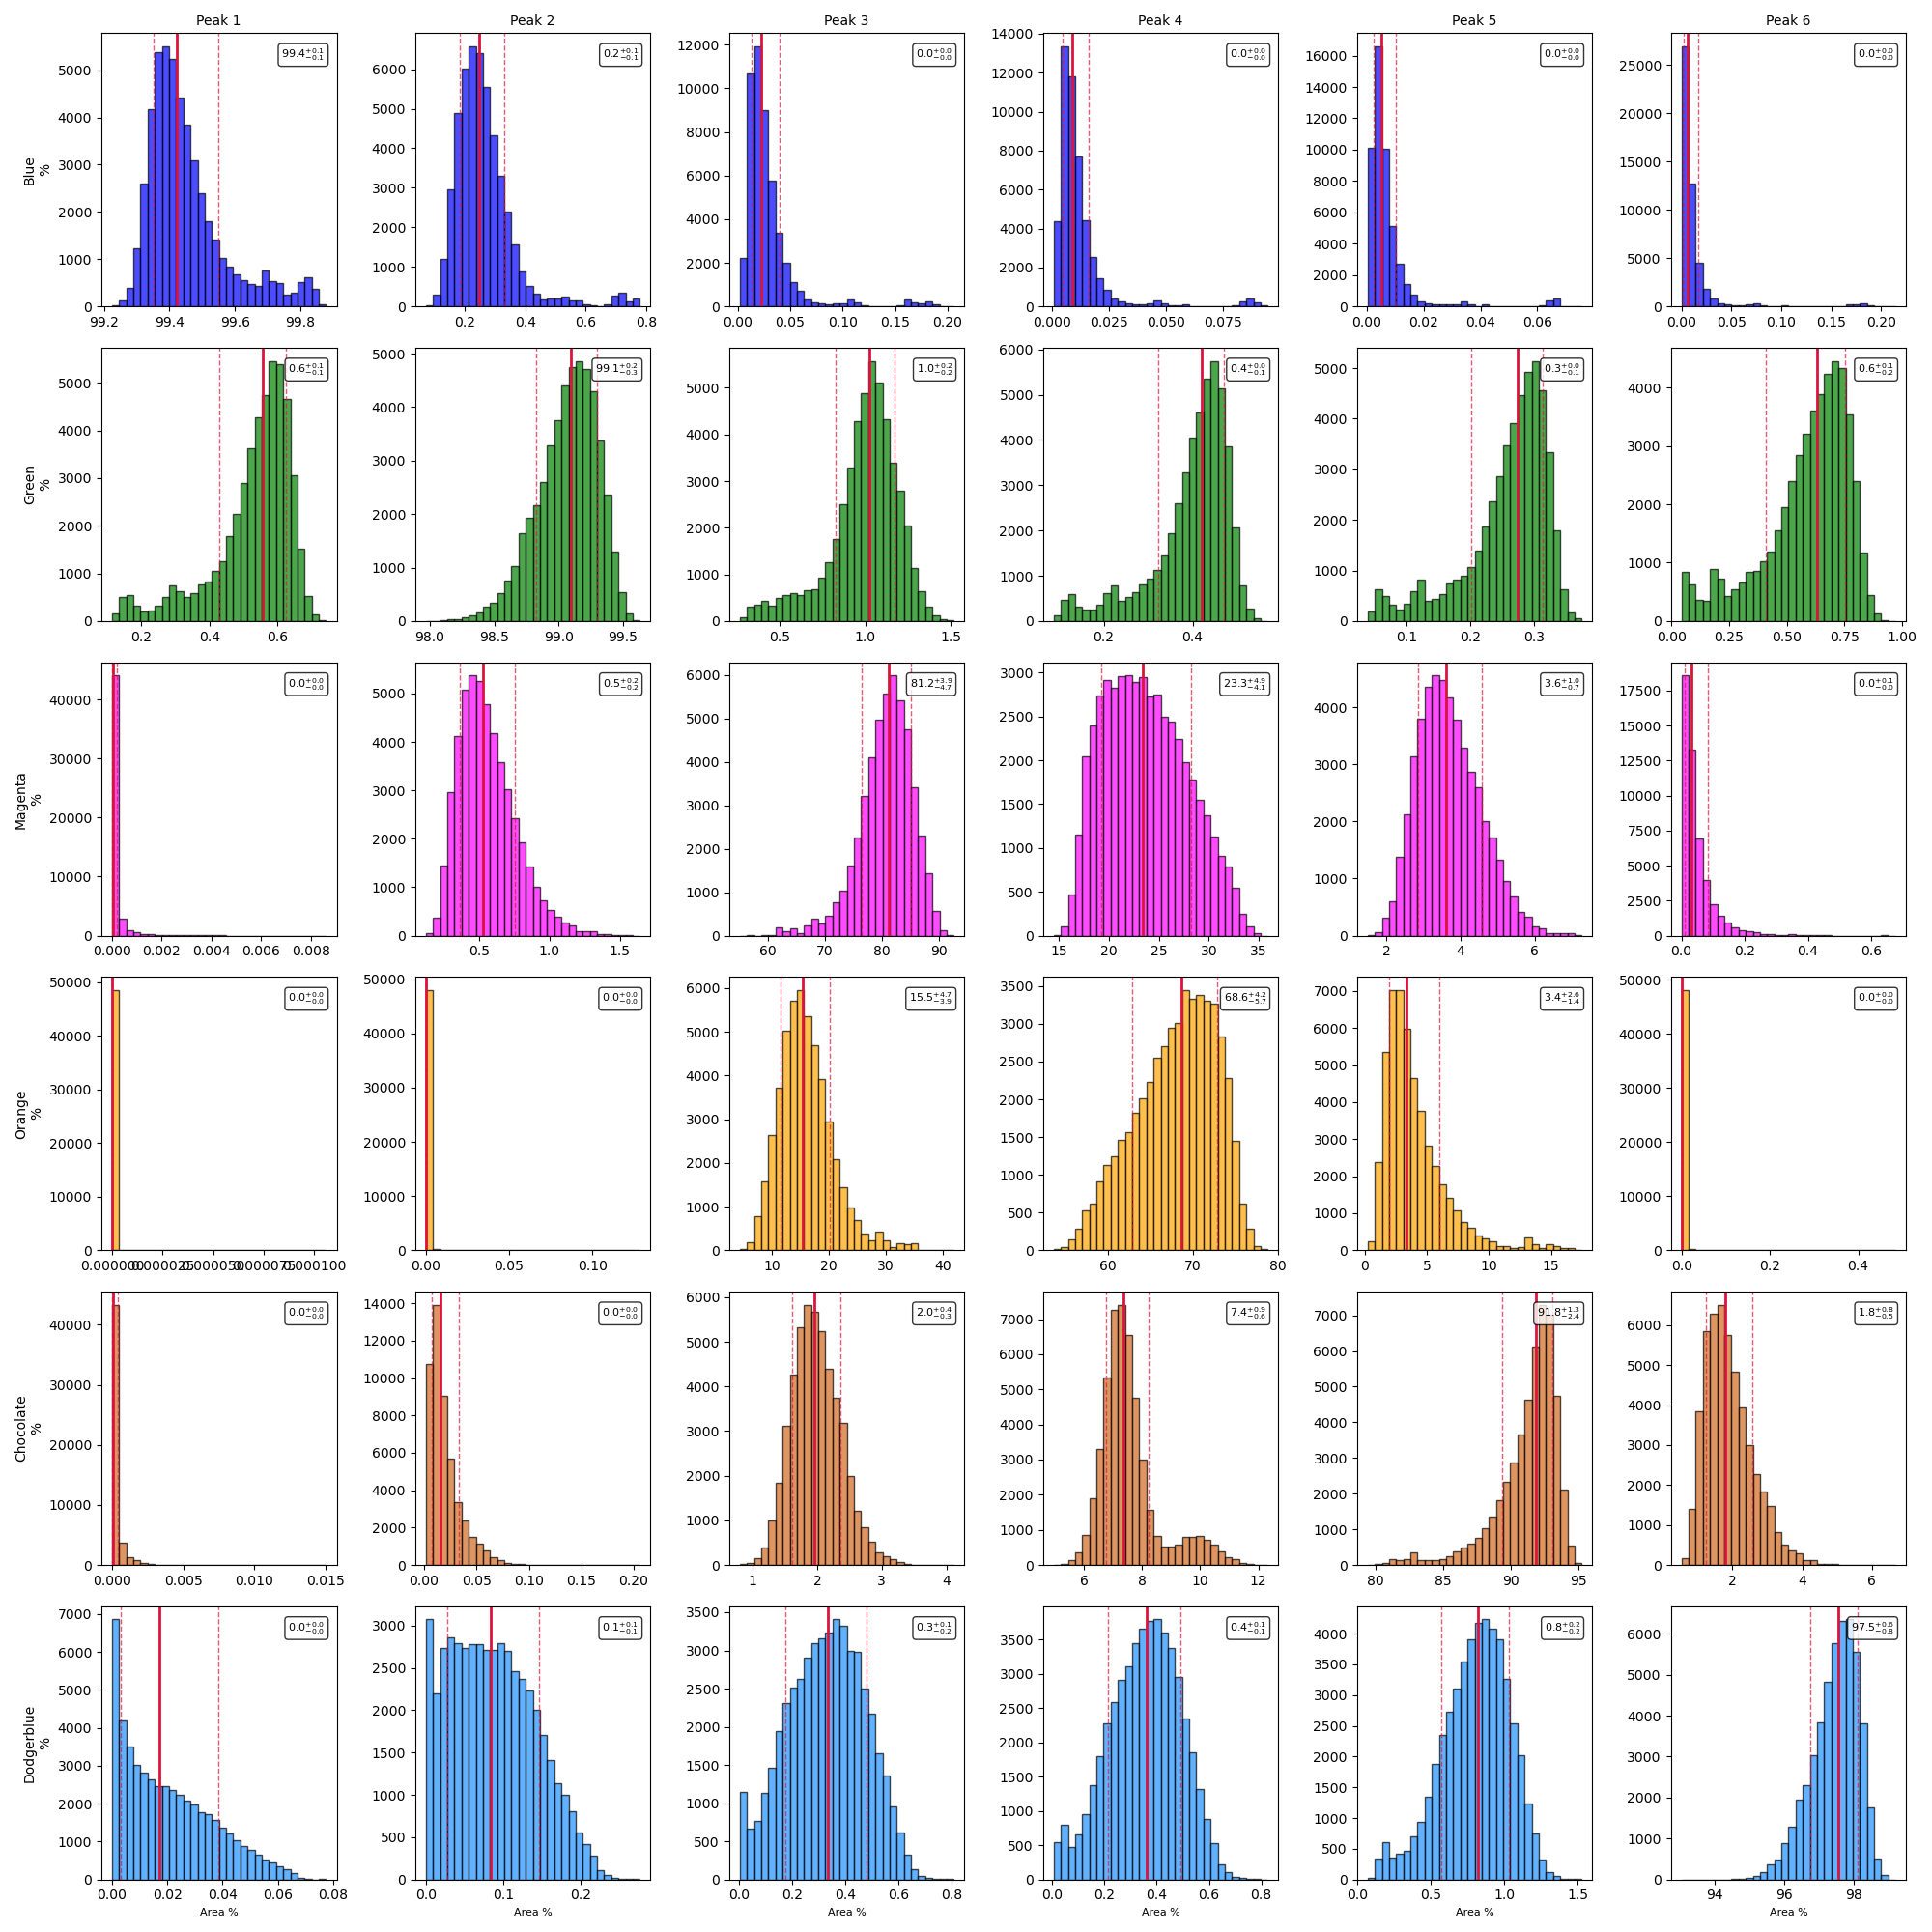

In [27]:
# Plot di tutte le distribuzioni (6x6 = 36 subplot)
fig, axes = plt.subplots(6, 6, figsize=(20, 20))
components = ['Blue', 'Green', 'Magenta', 'Orange', 'Chocolate', 'Dodgerblue']
peaks = [f'Peak {i+1}' for i in range(6)]
colors = ['blue', 'green', 'magenta', 'orange', 'chocolate', 'dodgerblue']

for comp_idx in range(6):
    for peak_idx in range(6):
        ax = axes[comp_idx, peak_idx]
        data = all_areas[:, comp_idx, peak_idx]
        
        # Istogramma
        ax.hist(data, bins=30, alpha=0.7, edgecolor='black', color=colors[comp_idx])
        
        # Aggiungi mediana e percentili
        median = np.median(data)
        p16 = np.percentile(data, 16)
        p84 = np.percentile(data, 84)
        
        ax.axvline(median, color='crimson', linestyle='-', linewidth=2, label='Mediana')
        ax.axvline(p16, color='crimson', linestyle='--', linewidth=1, alpha=0.7)
        ax.axvline(p84, color='crimson', linestyle='--', linewidth=1, alpha=0.7)
        
        # Titoli e label
        if comp_idx == 0:
            ax.set_title(peaks[peak_idx], fontsize=10)
        if peak_idx == 0:
            ax.set_ylabel(f'{components[comp_idx]}\n%', fontsize=10)
        if comp_idx == 5:
            ax.set_xlabel('Area %', fontsize=8)
        
        # Aggiungi testo con statistiche
        ax.text(0.95, 0.95, f'{median:.1f}$^{{+{p84-median:.1f}}}_{{-{median-p16:.1f}}}$',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('distributions_all_areas_3s.png', dpi=150, bbox_inches='tight')
plt.show()